# Spiegazione SHAP

In [1]:
import os
import joblib
import shap
from dotenv import load_dotenv
from xgboost import XGBClassifier

load_dotenv()
os.chdir("..")

MODELDIR = os.getenv("MODELDIR")
DATADIR = os.getenv("DATADIR")

xgb = XGBClassifier()
xgb.load_model(f"{MODELDIR}/xgb_model.ubj")
X_test, y_test = joblib.load(f"{DATADIR}/test_data.pkl")

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(X_test.shape)

/Users/mattiadanisi/Desktop/XAI-People-Analytics/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(294, 44)


### Creiamo lo SHAP Explainer

In [2]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(shap_values.shape)

(294, 44)


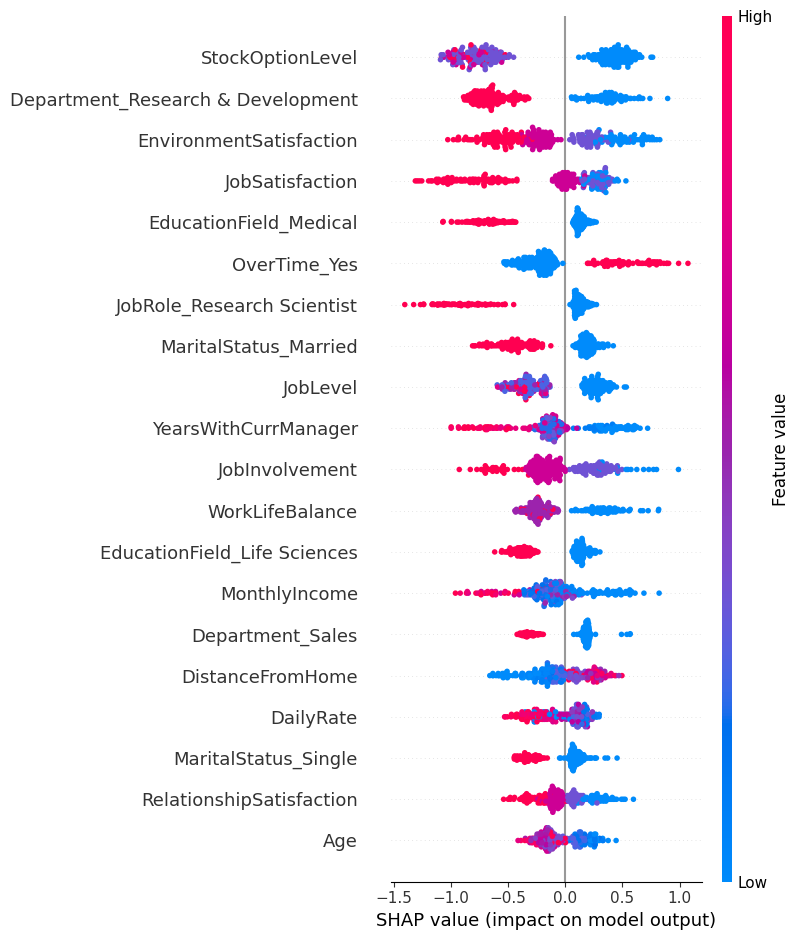

In [3]:
# Global summary plot — ranks features by their average impact on attrition
shap.summary_plot(shap_values, X_test)

Il grafico mostra l'impatto di ciascuna feature sulla previsione del modello per tutti i 294 (~20% del dataset) dipendenti del test set. Ogni punto rappresenta un dipendente: la posizione sull'asse orizzontale indica l'intensità e la direzione dell'impatto (valori positivi spingono verso l'abbandono, valori negativi verso la permanenza), mentre il colore indica il valore della feature per quell'individuo (rosso = valore alto, blu = valore basso).
Le osservazioni principali sono le seguenti. StockOptionLevel è la feature più influente: dipendenti con pochi o nessun stock option (blu) mostrano un rischio di abbandono significativamente più alto. OverTime_Yes presenta il pattern opposto: fare straordinari (rosso) spinge fortemente verso l'abbandono. EnvironmentSatisfaction e JobSatisfaction confermano l'intuizione HR classica: bassa soddisfazione aumenta il rischio di turnover. MonthlyIncome mostra che i dipendenti con reddito più basso (blu) tendono ad abbandonare di più. DistanceFromHome indica che distanze elevate dal luogo di lavoro aumentano il rischio.
È importante sottolineare che SHAP misura la correlazione tra feature e previsione, non la causalità. Il fatto che gli straordinari siano associati all'abbandono non implica necessariamente che ridurre gli straordinari trattenga i dipendenti — potrebbero esserci fattori sottostanti non presenti nel dataset. Queste evidenze vanno quindi interpretate come segnali da investigare, non come relazioni causa-effetto.

In [4]:
# Get predicted attrition probabilities for all test employees
y_proba = xgb.predict_proba(X_test)[:, 1]

for idx, proba in enumerate(y_proba):
    actual = "Left" if y_test.iloc[idx] == 1 else "Stayed"
    print(f"Employee {idx:3} | Predicted: {proba:.1%} | Actual: {actual}")

Employee   0 | Predicted: 82.2% | Actual: Stayed
Employee   1 | Predicted: 0.9% | Actual: Stayed
Employee   2 | Predicted: 28.6% | Actual: Stayed
Employee   3 | Predicted: 0.6% | Actual: Stayed
Employee   4 | Predicted: 49.9% | Actual: Left
Employee   5 | Predicted: 15.4% | Actual: Stayed
Employee   6 | Predicted: 4.5% | Actual: Stayed
Employee   7 | Predicted: 17.1% | Actual: Stayed
Employee   8 | Predicted: 1.2% | Actual: Stayed
Employee   9 | Predicted: 34.4% | Actual: Stayed
Employee  10 | Predicted: 14.5% | Actual: Stayed
Employee  11 | Predicted: 14.8% | Actual: Stayed
Employee  12 | Predicted: 8.0% | Actual: Stayed
Employee  13 | Predicted: 27.3% | Actual: Stayed
Employee  14 | Predicted: 37.7% | Actual: Stayed
Employee  15 | Predicted: 54.6% | Actual: Stayed
Employee  16 | Predicted: 7.1% | Actual: Stayed
Employee  17 | Predicted: 4.4% | Actual: Stayed
Employee  18 | Predicted: 34.3% | Actual: Stayed
Employee  19 | Predicted: 1.8% | Actual: Stayed
Employee  20 | Predicted: 60.0

## Case Study 1 — Vero Positivo (Employee 214)

### Predizione: 96.7% rischio abbandono | Esito reale: Left ✅

Il modello ha identificato correttamente questo dipendente come ad altissimo rischio di abbandono. L'analisi SHAP rivela un profilo di rischio composto da fattori negativi che si sommano senza alcuna forza controbilanciante: soddisfazione ambientale al minimo (1/4), straordinari frequenti, nessun stock option, livello retributivo entry-level (JobLevel 1), retribuzione mensile di soli 2.174€ e bassa soddisfazione lavorativa (2/4). Questo caso rappresenta l'esempio ideale di come il modello possa supportare l'HR: non solo segnalando il rischio, ma fornendo una spiegazione granulare e azionabile. Un manager HR avrebbe potuto intervenire su più fronti simultaneamente — retribuzione, carico di lavoro e soddisfazione ambientale — prima che il dipendente prendesse la decisione di lasciare.

Predicted: 96.7%
Actual: Left


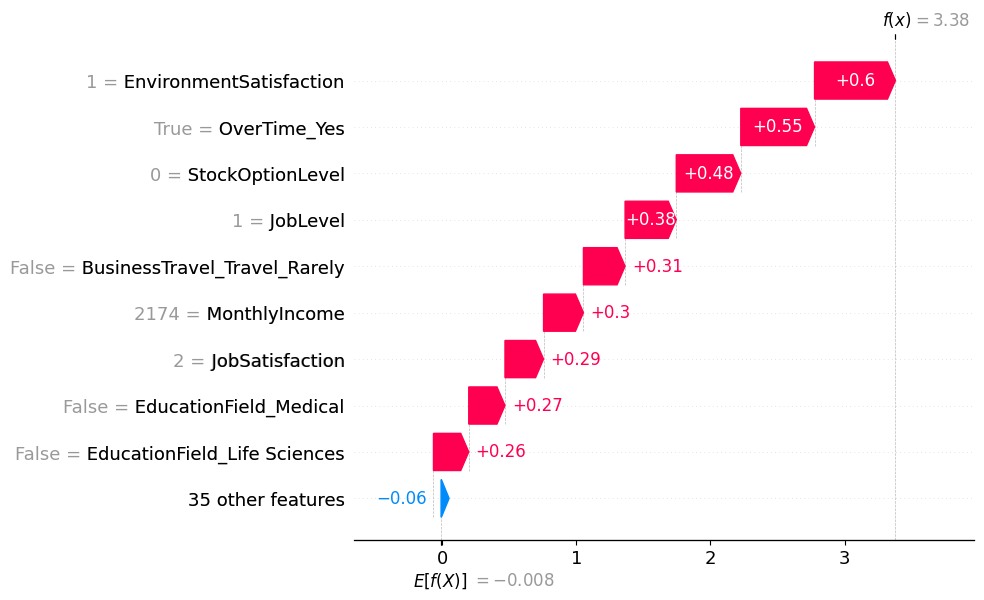

In [5]:
employee_idx = 214

print(f"Predicted: {y_proba[employee_idx]:.1%}")
print(f"Actual: {'Left' if y_test.iloc[employee_idx] == 1 else 'Stayed'}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[employee_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[employee_idx],
    feature_names=X_test.columns.tolist()
))

## Case Study 2 — Falso Positivo (Employee 223)

### Predizione: 86.1% rischio abbandono | Esito reale: Stayed ❌

Il modello ha segnalato questo dipendente come ad alto rischio, ma l'employee è rimasto in azienda. L'analisi SHAP mostra una situazione di tensione tra forze opposte: da un lato fattori di rischio significativi come retribuzione molto bassa (1.200€), nessun stock option, nessuna anzianità con il manager attuale e bassa soddisfazione relazionale; dall'altro fattori protettivi rilevanti come soddisfazione ambientale massima (4/4) e assenza di straordinari. Il modello ha sovrapesato i segnali quantitativi negativi, non riuscendo a cogliere il peso che la qualità dell'ambiente lavorativo e il bilanciamento vita-lavoro hanno avuto nella decisione del dipendente di restare. Questo caso evidenzia come le metriche oggettive da sole non bastino a catturare la complessità della soddisfazione lavorativa umana.


Predicted: 86.1%
Actual: Stayed


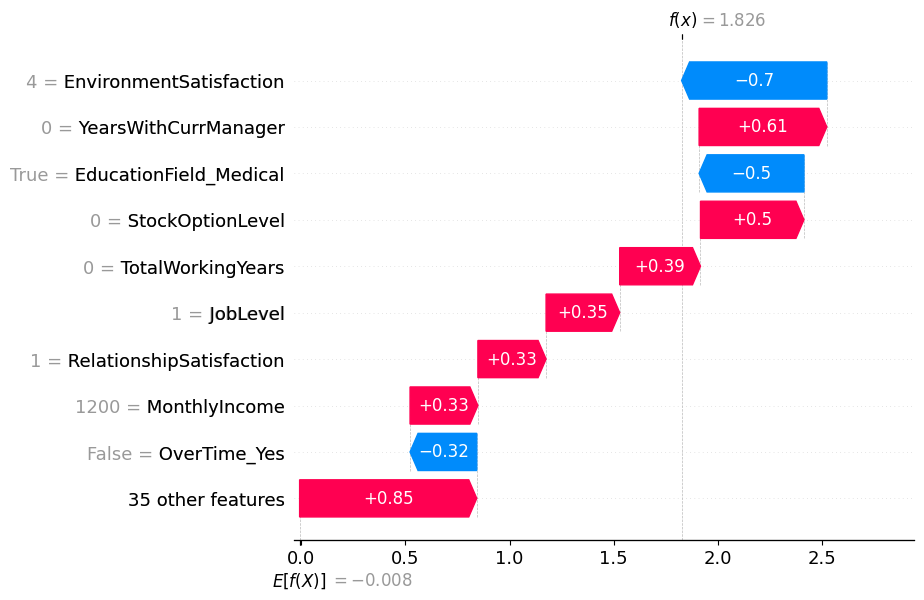

In [6]:
employee_idx = 223

print(f"Predicted: {y_proba[employee_idx]:.1%}")
print(f"Actual: {'Left' if y_test.iloc[employee_idx] == 1 else 'Stayed'}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[employee_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[employee_idx],
    feature_names=X_test.columns.tolist()
))

## Case Study 3 — Falso Negativo (Employee 240)

### Predizione: 0.7% rischio abbandono | Esito reale: Left ❌

Il caso più significativo dal punto di vista analitico. Il modello era estremamente sicuro che questo dipendente sarebbe rimasto — e si è completamente sbagliato. Il profilo SHAP mostra un dipendente con ogni possibile indicatore di retention: soddisfazione lavorativa massima (4/4), nove anni con lo stesso manager, stock option attivi, appartenenza al dipartimento R&D, nessuna azienda precedente, livello senior (JobLevel 3) e ottimo work-life balance. Non esiste un singolo fattore di rischio visibile. L'abbandono è stato quasi certamente guidato da ragioni non misurabili dal dataset — un'offerta esterna, una svolta personale, una dinamica interpersonale non registrata. Questo caso rappresenta il limite intrinseco di qualsiasi sistema predittivo basato su dati strutturati, e rafforza la tesi centrale del progetto: l'XAI non sostituisce il giudizio umano, ma lo supporta fornendo trasparenza su ciò che è misurabile.

StockOptionLevel                        1
NumCompaniesWorked                      0
Department_Research & Development    True
JobRole_Manufacturing Director       True
MaritalStatus_Married                True
Age                                    53
DistanceFromHome                        2
Name: 240, dtype: object
Predicted: 0.7%
Actual: Left


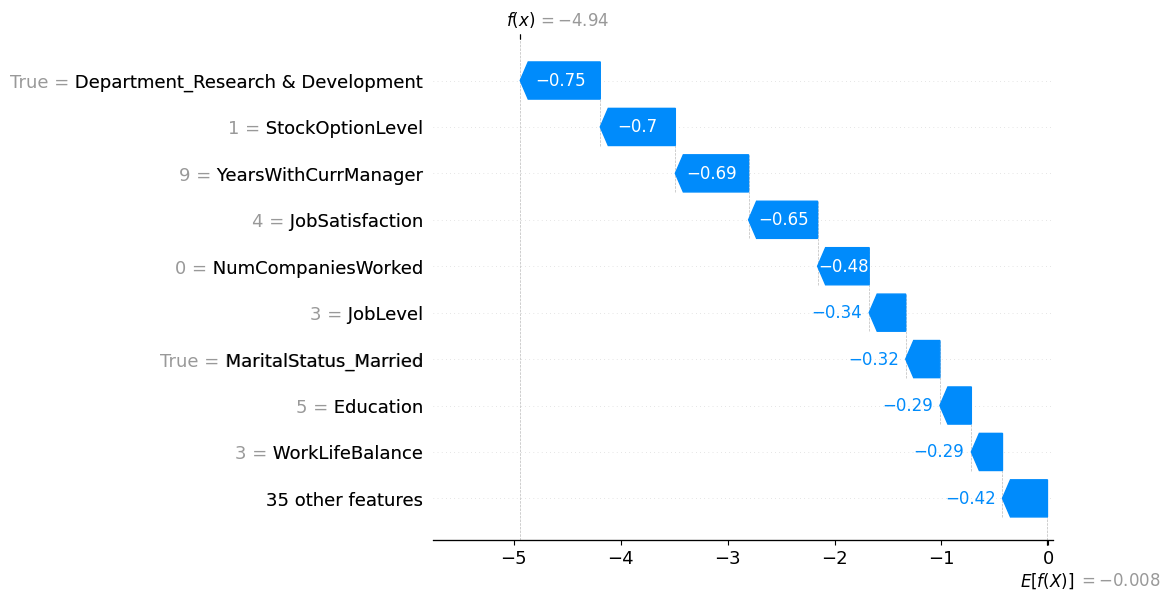

In [7]:
employee_idx = 240

print(X_test.iloc[240][["StockOptionLevel", "NumCompaniesWorked",
                          "Department_Research & Development",
                          "JobRole_Manufacturing Director",
                          "MaritalStatus_Married", "Age",
                          "DistanceFromHome"]])

print(f"Predicted: {y_proba[employee_idx]:.1%}")
print(f"Actual: {'Left' if y_test.iloc[employee_idx] == 1 else 'Stayed'}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[employee_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[employee_idx],
    feature_names=X_test.columns.tolist()
))